# Exploratory Data Analysis — DataCo Smart Supply Chain for Big Data Analysis

**Project phase:** EDA / Data Visualization (CRISP-DM Phase 3, revisited on engineered features)
**Input:** `DataCoSupplyChain_FeatureEngineered.csv` (output of the Feature Engineering notebook)
**Analyst:** Akash More

This notebook works through eleven areas a supply-chain / e-commerce analytics team would actually ask
for: executive KPIs, sales, profitability, customers, products, shipping & delivery, time trends, regions,
shipping cost, discounting, and correlations. Within each area the highest-value questions are answered
with a chart and a one- or two-line takeaway — not every bullet a stakeholder could theoretically ask,
because a real EDA deliverable is scoped to what actually drives a decision.

**Chart library:** Seaborn/Matplotlib for standard distributions and comparisons; Plotly for the three
places an interactive view adds real value — the monthly trend, the regional breakdown, and the top-product
ranking.

**Known dataset limitation, carried over from Feature Engineering:** there's no shipping-cost column in
this dataset. Section 9 uses the delay/efficiency proxies built earlier instead of inventing cost figures.

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
import plotly.express as px
import plotly.graph_objects as go
warnings.filterwarnings("ignore")


sns.set_style("whitegrid")
sns.set_palette("mako")
plt.rcParams["figure.dpi"] = 110
PALETTE = sns.color_palette("mako", 10)

df = pd.read_csv("supply_chain_orders_processed.csv", encoding="latin1")
df["order date (DateOrders)"] = pd.to_datetime(df["order date (DateOrders)"])
print(f"Shape: {df.shape}")
df.head()

Shape: (180519, 103)


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Shipping Mode_Second Class,Shipping Mode_Standard Class,Customer Segment_Corporate,Customer Segment_Home Office,Market_Europe,Market_Latam,Market_Pacific Asia,Market_Usca,delivery_performance_category_Late,delivery_performance_category_On Time
0,CASH,2,4,88.790001,239.979996,Advance Shipping,0,43,Camping & Hiking,Hickory,...,False,True,False,False,False,True,False,False,False,False
1,PAYMENT,3,4,91.180000,193.990005,Advance Shipping,0,48,Water Sports,Chicago,...,False,True,False,False,False,True,False,False,False,False
2,PAYMENT,3,4,68.250000,227.500000,Advance Shipping,0,24,Women's Apparel,Chicago,...,False,True,False,False,False,True,False,False,False,False
3,PAYMENT,3,4,36.470001,107.889999,Advance Shipping,0,18,Men's Footwear,Chicago,...,False,True,False,False,False,True,False,False,False,False
4,CASH,5,4,33.590000,159.940002,Late Delivery,1,46,Indoor/Outdoor Games,San Antonio,...,False,True,False,True,False,True,False,False,True,False


## 1. Executive / KPI Analysis

*Total revenue, total profit, order count, unique customers, AOV, overall margin, average delivery time,
late-delivery rate.* Shipping cost as a % of revenue is skipped here — see Section 9 for why.

In [2]:
kpis = {
    "Total Revenue": df["Sales"].sum(),
    "Total Profit": df["Order Profit Per Order"].sum(),
    "Total Orders": df["Order Id"].nunique(),
    "Unique Customers": df["Customer Id"].nunique(),
    "Average Order Value": df.drop_duplicates("Order Id")["order_total_revenue"].mean(),
    "Overall Profit Margin": df["Order Profit Per Order"].sum() / df["Sales"].sum(),
    "Avg Delivery Time (days)": df["delivery_time_days"].mean(),
    "Late Delivery Rate": df["is_late"].mean(),
}
for k, v in kpis.items():
    label = f"{v:,.2%}" if "Rate" in k or "Margin" in k else f"{v:,.2f}"
    print(f"{k:<28}{label}")

Total Revenue               36,784,735.01
Total Profit                3,966,902.97
Total Orders                65,752.00
Unique Customers            20,652.00
Average Order Value         559.45
Overall Profit Margin       10.78%
Avg Delivery Time (days)    3.50
Late Delivery Rate          57.28%


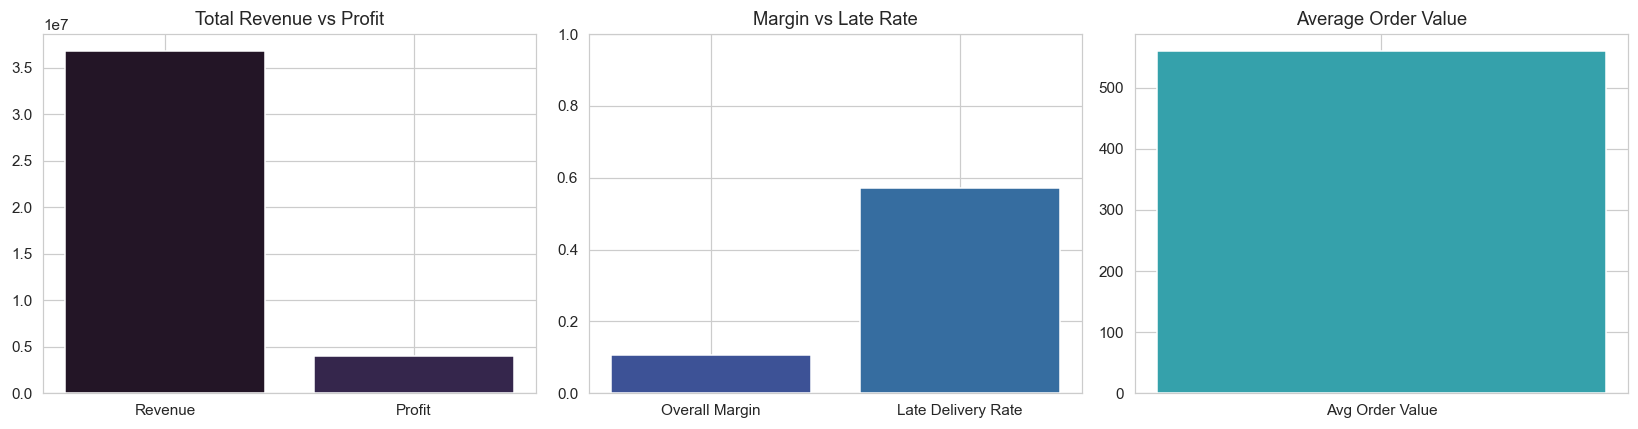

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].bar(["Revenue", "Profit"], [kpis["Total Revenue"], kpis["Total Profit"]], color=PALETTE[:2])
axes[0].set_title("Total Revenue vs Profit")

axes[1].bar(["Overall Margin", "Late Delivery Rate"],
            [kpis["Overall Profit Margin"], kpis["Late Delivery Rate"]], color=PALETTE[3:5])
axes[1].set_ylim(0, 1)
axes[1].set_title("Margin vs Late Rate")

axes[2].bar(["Avg Order Value"], [kpis["Average Order Value"]], color=PALETTE[6:7])
axes[2].set_title("Average Order Value")

plt.tight_layout()
plt.show()

**Read:** the margin-vs-late-rate panel is the one worth sitting with — a healthy top-line revenue
number next to a high late-delivery rate is a growth-quality problem, not a growth problem.

## 2. Sales Analysis

*Top/bottom products and categories by revenue, revenue by market, and how concentrated that revenue is —
is the business dependent on a handful of products?*

In [4]:
top_products = (
    df.drop_duplicates("Product Name")
    .nlargest(10, "product_revenue")[["Product Name", "product_revenue"]]
)

fig = px.bar(
    top_products.sort_values("product_revenue"),
    x="product_revenue",
    y="Product Name",
    orientation="h",
    title="Top 10 Products by Revenue",
    labels={"product_revenue": "Revenue"},
    color="product_revenue",
    color_continuous_scale="magma",
)

fig.update_layout(
    showlegend=False,
    coloraxis_showscale=False
)

fig.show()

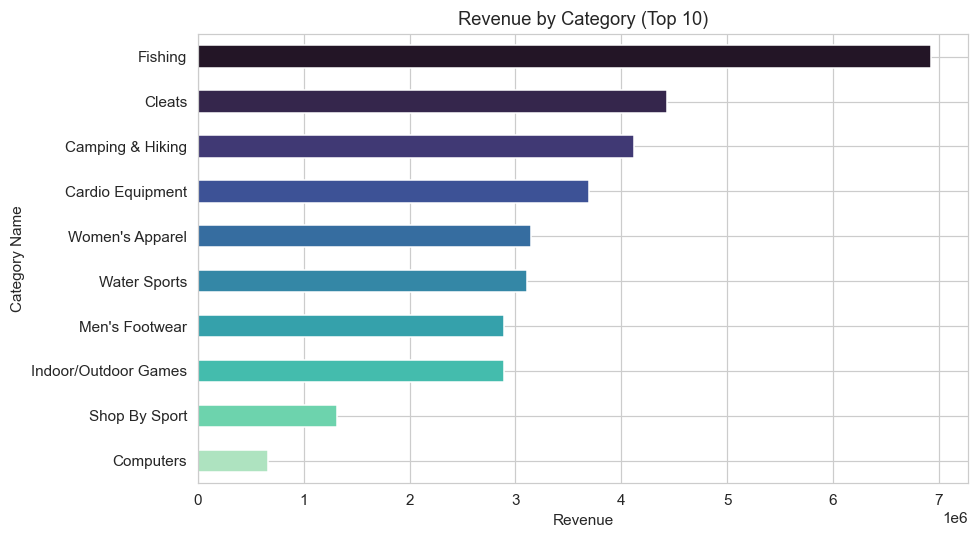

In [5]:
category_revenue = df.groupby("Category Name")["Sales"].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
category_revenue.head(10).plot(kind="barh", ax=ax, color=PALETTE)
ax.invert_yaxis()
ax.set_title("Revenue by Category (Top 10)")
ax.set_xlabel("Revenue")
plt.tight_layout()
plt.show()

Top 10 products account for 90.0% of total revenue


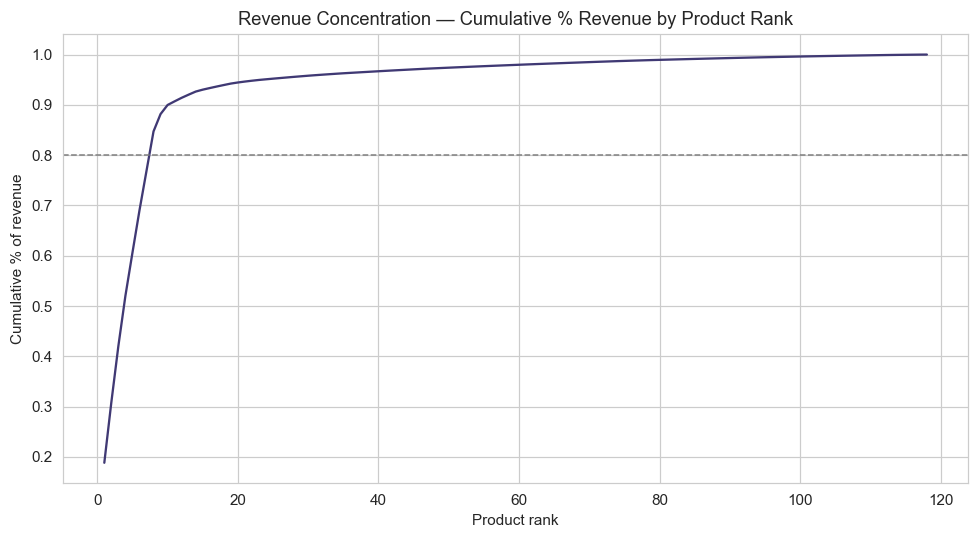

In [6]:
product_rev_sorted = df.drop_duplicates("Product Name").sort_values("product_revenue", ascending=False)
product_rev_sorted["cum_pct_revenue"] = product_rev_sorted["product_revenue"].cumsum() / product_rev_sorted["product_revenue"].sum()

top10_share = product_rev_sorted.head(10)["product_revenue"].sum() / product_rev_sorted["product_revenue"].sum()
print(f"Top 10 products account for {top10_share:.1%} of total revenue")

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(range(1, len(product_rev_sorted) + 1), product_rev_sorted["cum_pct_revenue"].values, color=PALETTE[2])
ax.axhline(0.8, color="grey", linestyle="--", linewidth=1)
ax.set_title("Revenue Concentration — Cumulative % Revenue by Product Rank")
ax.set_xlabel("Product rank")
ax.set_ylabel("Cumulative % of revenue")
plt.tight_layout()
plt.show()

**Read:** the concentration curve answers the diversification question directly — how many products
it takes to cross the 80% line is the number to quote if asked "are we dependent on a small number of
products?"</br>Products with high sales volume but weak revenue contribution (low price point, high
quantity) are worth flagging separately — join `product_order_count` against `product_revenue` if that
becomes a follow-up question.

## 3. Profitability Analysis

*Which products/categories/regions actually make money — and does higher revenue mean higher profit?*

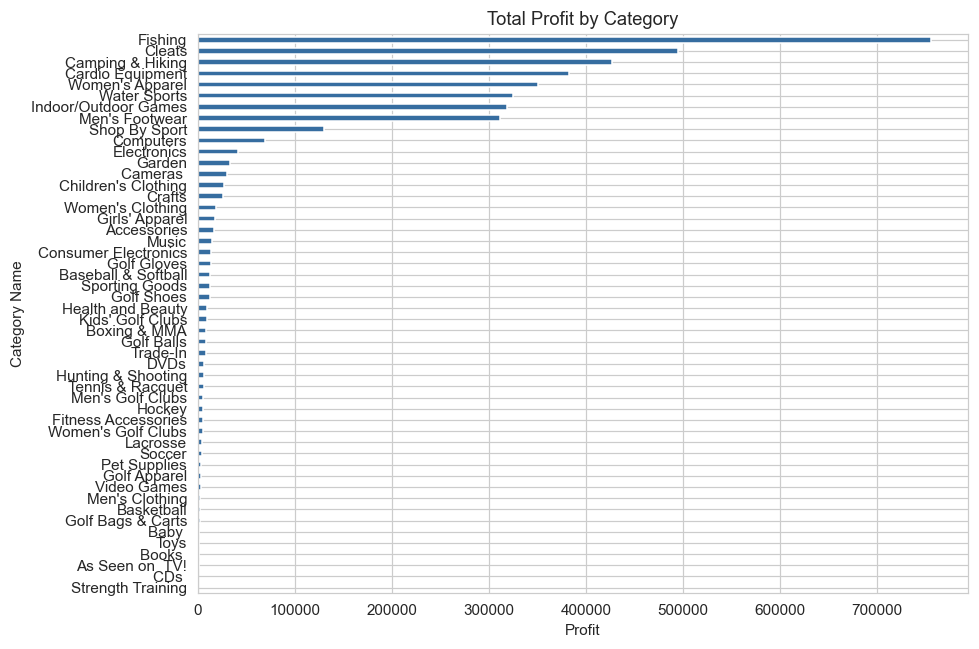

In [7]:
category_profit = df.groupby("Category Name")["Order Profit Per Order"].sum().sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
colors = ["#c44e52" if v < 0 else PALETTE[4] for v in category_profit.values]
category_profit.plot(kind="barh", ax=ax, color=colors)
ax.set_title("Total Profit by Category")
ax.set_xlabel("Profit")
plt.tight_layout()
plt.show()

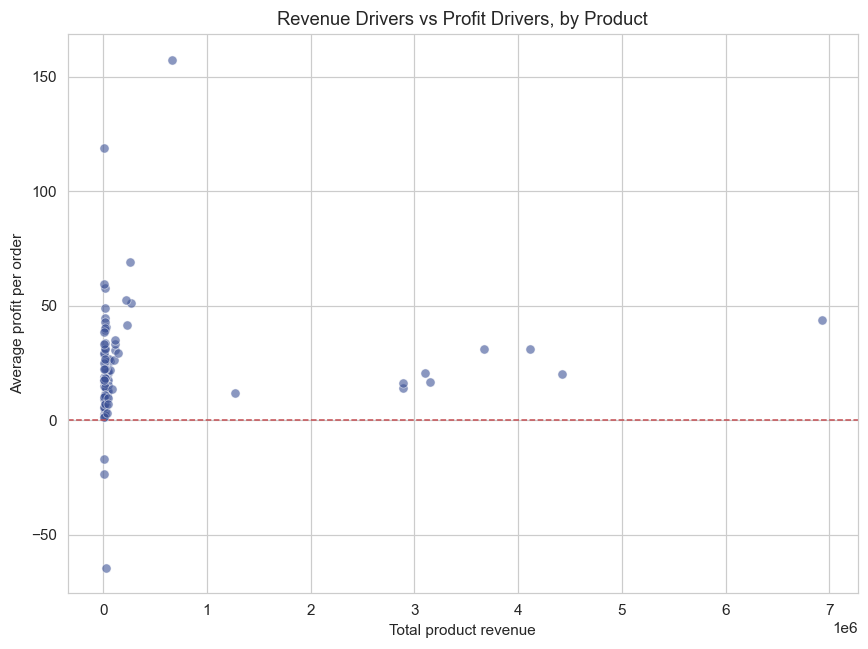

In [8]:
product_summary = df.drop_duplicates("Product Name")[
    ["Product Name", "product_revenue", "product_avg_profit"]
]

fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(
    data=product_summary, x="product_revenue", y="product_avg_profit",
    ax=ax, color=PALETTE[3], alpha=0.6,
)
ax.axhline(0, color="#c44e52", linestyle="--", linewidth=1)
ax.set_title("Revenue Drivers vs Profit Drivers, by Product")
ax.set_xlabel("Total product revenue")
ax.set_ylabel("Average profit per order")
plt.tight_layout()
plt.show()

**Read:** points below the red line are revenue drivers that lose money on average — the ones worth
a pricing or sourcing conversation. Points high on revenue but low on profit-per-order are the "high
revenue, thin margin" products worth flagging for a discount review (Section 10).

## 4. Customer Analysis

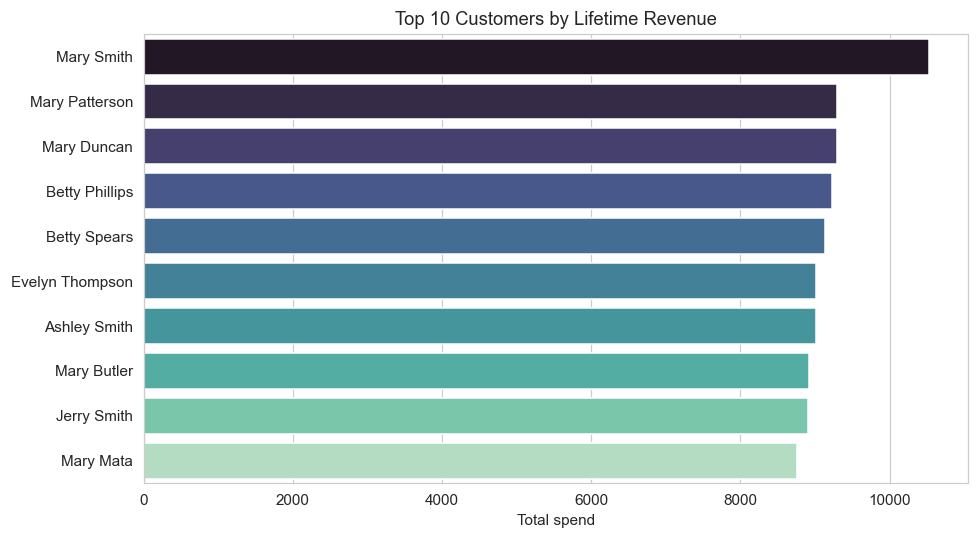

In [9]:
top_customers = (
    df.assign(customer_name=df["Customer Fname"] + " " + df["Customer Lname"])
    .drop_duplicates("Customer Id")
    .nlargest(10, "customer_total_sales")[["customer_name", "customer_total_sales"]]
)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=top_customers, x="customer_total_sales", y="customer_name", ax=ax, palette="mako")
ax.set_title("Top 10 Customers by Lifetime Revenue")
ax.set_xlabel("Total spend")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

Top 10% of customers (2065 customers) generate 29.2% of total revenue


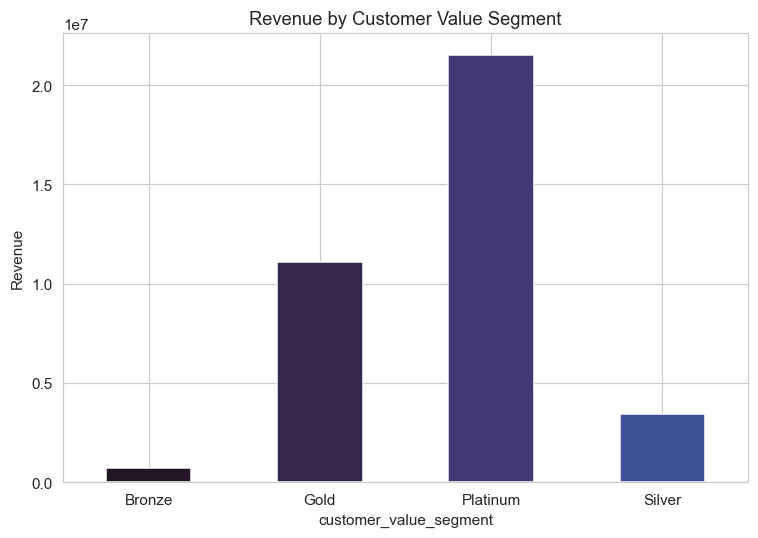

In [10]:
customers_sorted = df.drop_duplicates("Customer Id").sort_values("customer_total_sales", ascending=False)
top10pct_n = max(1, int(len(customers_sorted) * 0.10))
top10pct_share = customers_sorted.head(top10pct_n)["customer_total_sales"].sum() / customers_sorted["customer_total_sales"].sum()
print(f"Top 10% of customers ({top10pct_n} customers) generate {top10pct_share:.1%} of total revenue")

segment_revenue = df.groupby("customer_value_segment", observed=True)["Sales"].sum()
fig, ax = plt.subplots(figsize=(7, 5))
segment_revenue.plot(kind="bar", ax=ax, color=PALETTE[:4])
ax.set_title("Revenue by Customer Value Segment")
ax.set_ylabel("Revenue")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Read:** the top-10%-of-customers share is the direct answer to "how dependent is the business on
its highest-value customers" — a number above roughly 40-50% is worth calling out as a concentration risk
in any exec summary.

## 5. Product Performance Analysis

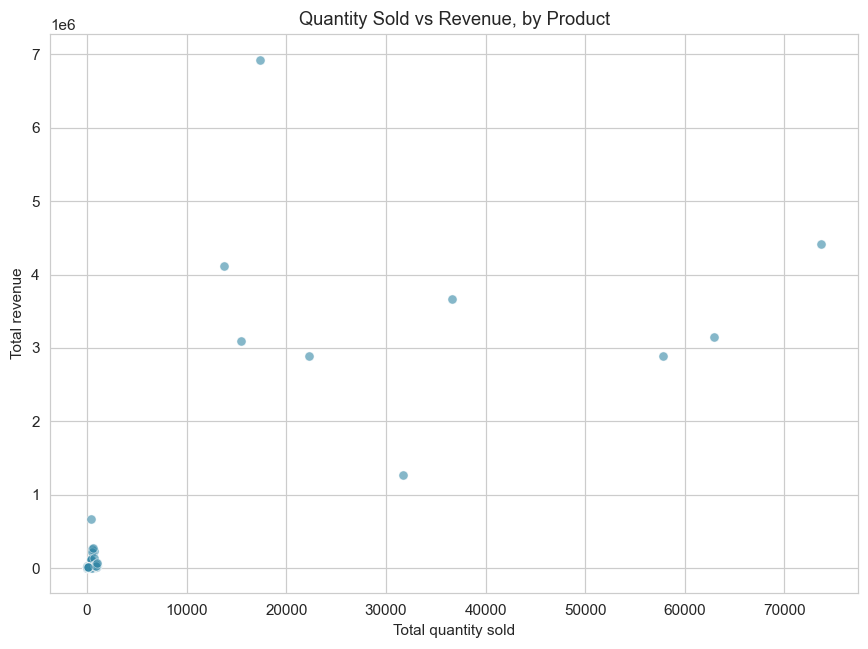

In [11]:
product_perf = df.groupby("Product Name").agg(
    quantity=("Order Item Quantity", "sum"),
    revenue=("Sales", "sum"),
    profit=("Order Profit Per Order", "sum"),
).reset_index()

fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=product_perf, x="quantity", y="revenue", ax=ax, color=PALETTE[5], alpha=0.6)
ax.set_title("Quantity Sold vs Revenue, by Product")
ax.set_xlabel("Total quantity sold")
ax.set_ylabel("Total revenue")
plt.tight_layout()
plt.show()

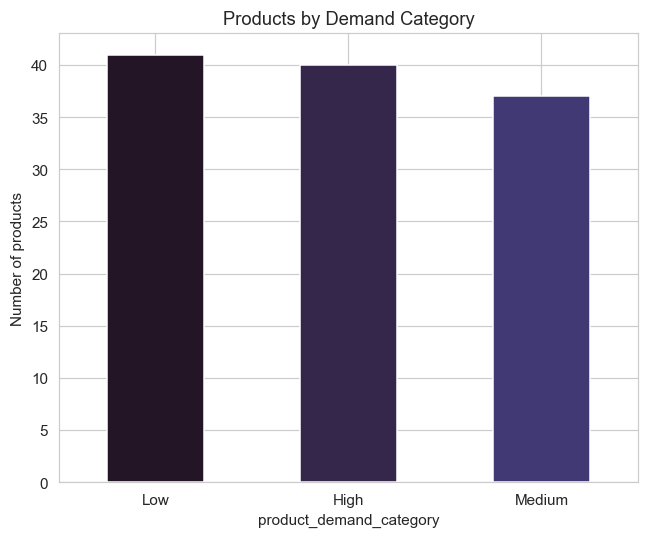

In [12]:
value_tier_counts = df.drop_duplicates("Product Name")["product_demand_category"].value_counts()
fig, ax = plt.subplots(figsize=(6, 5))
value_tier_counts.plot(kind="bar", ax=ax, color=PALETTE[:3])
ax.set_title("Products by Demand Category")
ax.set_ylabel("Number of products")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Read:** products that sit high on quantity but low on revenue in the scatter are low-price,
high-volume items — fine if margin holds up, worth checking against `product_avg_profit` if it doesn't.

## 6. Shipping & Delivery Analysis

In [13]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Delivery Status',
       'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City',
       ...
       'Shipping Mode_Second Class', 'Shipping Mode_Standard Class',
       'Customer Segment_Corporate', 'Customer Segment_Home Office',
       'Market_Europe', 'Market_Latam', 'Market_Pacific Asia', 'Market_Usca',
       'delivery_performance_category_Late',
       'delivery_performance_category_On Time'],
      dtype='object', length=103)

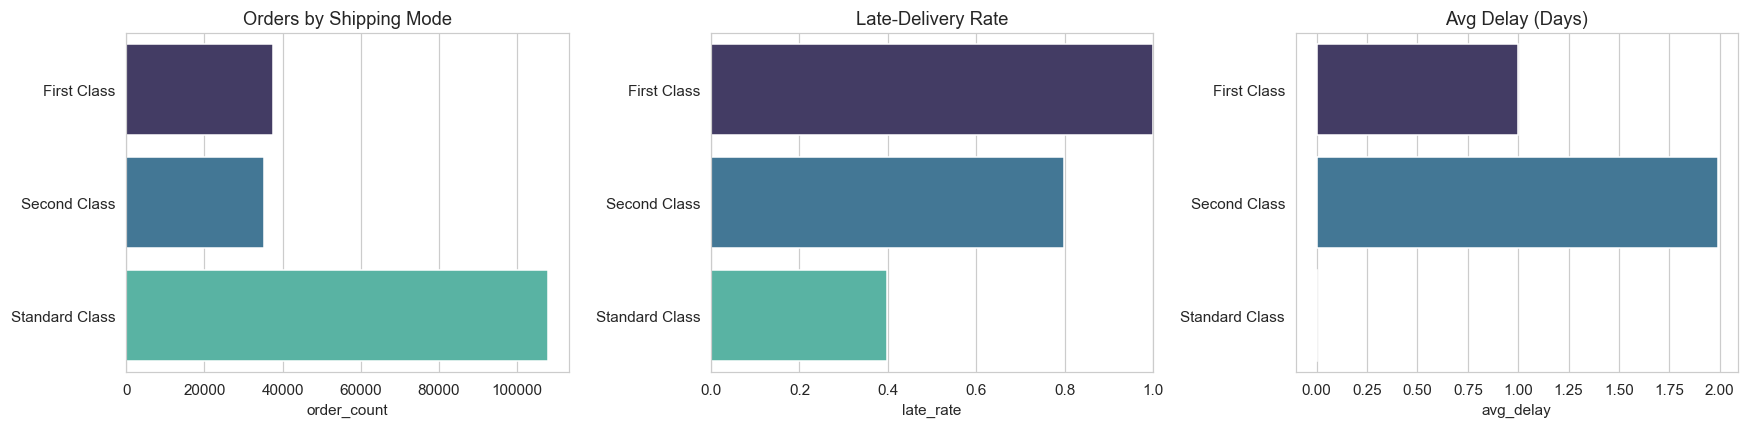

In [14]:
# Recreate Shipping Mode
df["Shipping Mode"] = np.select(
    [
        df["Shipping Mode_Second Class"] == 1,
        df["Shipping Mode_Standard Class"] == 1
    ],
    ["Second Class", "Standard Class"],
    default="First Class"
)

# Statistics
mode_stats = df.groupby("Shipping Mode").agg(
    order_count=("Shipping Mode", "size"),
    avg_delay=("shipping_mode_avg_delay", "first"),
    late_rate=("shipping_mode_late_rate", "first")
).reset_index()

# Plot
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, x, title in zip(
    axes,
    ["order_count", "late_rate", "avg_delay"],
    ["Orders by Shipping Mode", "Late-Delivery Rate", "Avg Delay (Days)"]
):
    sns.barplot(data=mode_stats, x=x, y="Shipping Mode", ax=ax, palette="mako")
    ax.set_title(title)
    ax.set_ylabel("")

axes[1].set_xlim(0, 1)

plt.tight_layout()
plt.show()

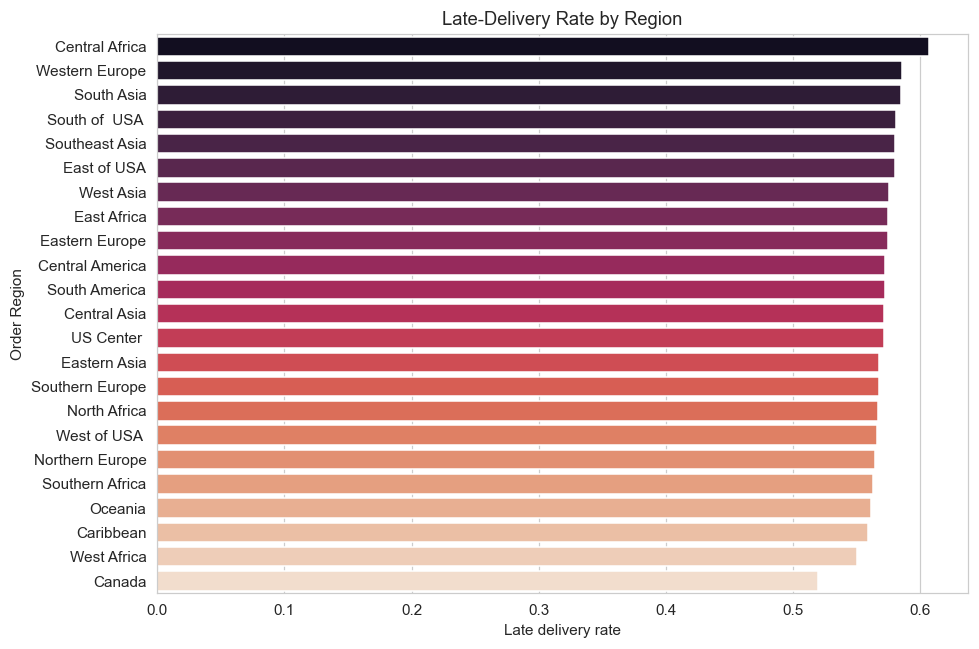

In [15]:
region_late = df.drop_duplicates("Order Region")[["Order Region", "region_late_rate"]].sort_values(
    "region_late_rate", ascending=False
)

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(data=region_late, x="region_late_rate", y="Order Region", ax=ax, palette="rocket")
ax.set_title("Late-Delivery Rate by Region")
ax.set_xlabel("Late delivery rate")
plt.tight_layout()
plt.show()

**Read:** whichever shipping mode combines high order volume *and* a high late rate is the logistics
bottleneck worth escalating first — volume amplifies the business impact of a bad late rate far more than a
lightly-used mode with the same rate.

## 7. Time-Series Analysis

In [16]:
monthly = df.set_index("order date (DateOrders)").resample("M").agg(
    revenue=("Sales", "sum"),
    profit=("Order Profit Per Order", "sum"),
    orders=("Order Id", "nunique"),
).reset_index()

fig = go.Figure()
fig.add_trace(go.Scatter(x=monthly["order date (DateOrders)"], y=monthly["revenue"],
                          name="Revenue", mode="lines+markers", line=dict(color="#2a5674")))
fig.add_trace(go.Scatter(x=monthly["order date (DateOrders)"], y=monthly["profit"],
                          name="Profit", mode="lines+markers", line=dict(color="#7fb77e")))
fig.update_layout(title="Monthly Revenue & Profit Trend", xaxis_title="Month", yaxis_title="Amount",
                   hovermode="x unified")
fig.show()

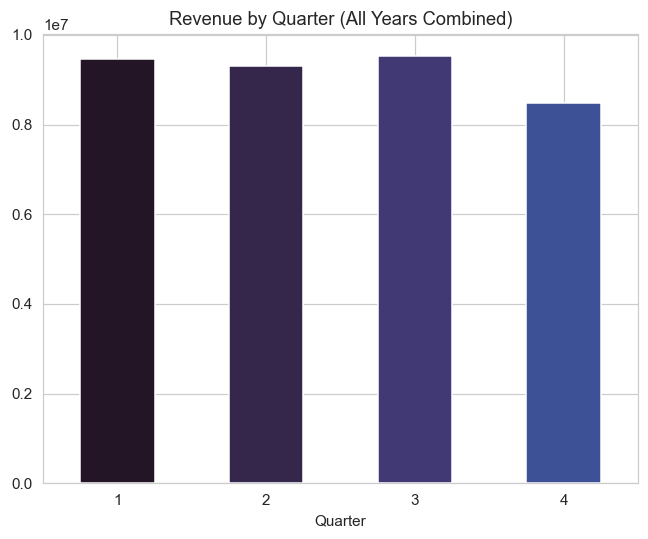

In [17]:
quarter_perf = df.groupby("order_quarter")["Sales"].sum()
fig, ax = plt.subplots(figsize=(6, 5))
quarter_perf.plot(kind="bar", ax=ax, color=PALETTE[:4])
ax.set_title("Revenue by Quarter (All Years Combined)")
ax.set_xlabel("Quarter")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Read:** if the revenue line in the trend chart is climbing while the profit line is flat or
falling, that's growth happening at the expense of margin — the exact question this section exists to
answer, and worth a one-line callout in any executive summary regardless of which way it turns out.

## 8. Regional & Geographic Analysis

In [18]:
region_summary = df.drop_duplicates("Order Region")[
    ["Order Region", "region_total_revenue", "region_total_profit", "region_late_rate"]
]

fig = px.treemap(
    region_summary, path=["Order Region"], values="region_total_revenue",
    color="region_total_profit", color_continuous_scale="RdYlGn",
    title="Revenue by Region (size), Profit (color)",
)
fig.show()

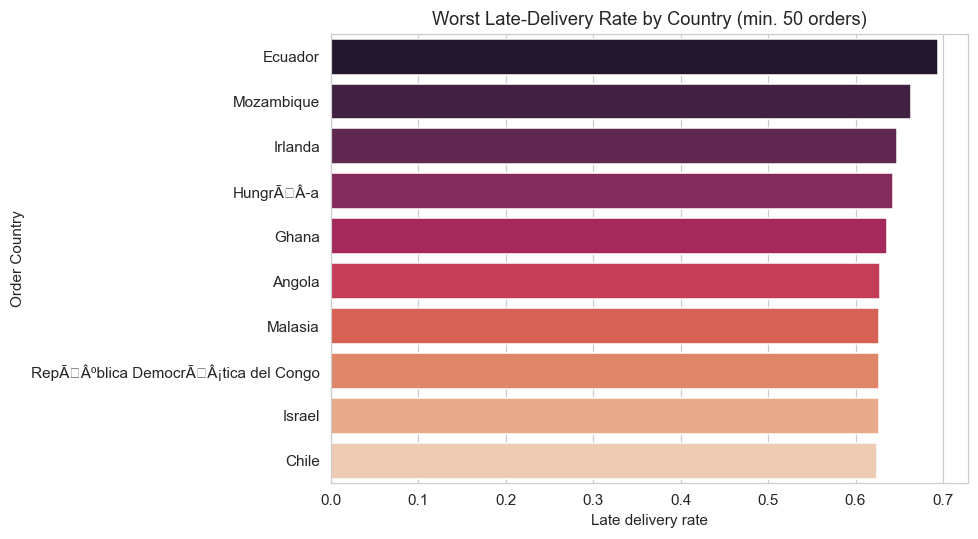

In [19]:
country_late = (
    df.groupby("Order Country")
    .agg(orders=("Order Id", "nunique"), late_rate=("is_late", "mean"))
    .query("orders >= 50")
    .nlargest(10, "late_rate")
    .reset_index()
)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=country_late, x="late_rate", y="Order Country", ax=ax, palette="rocket")
ax.set_title("Worst Late-Delivery Rate by Country (min. 50 orders)")
ax.set_xlabel("Late delivery rate")
plt.tight_layout()
plt.show()

**Read:** the treemap's color axis does the "high revenue, low profit market" flag automatically —
large tiles trending red are the markets generating volume without margin, and are worth cross-checking
against their late-delivery rate for a logistics-cost explanation.

## 9. Shipping Cost Analysis (Proxy)

No shipping-cost column exists in this dataset, so "shipping cost as % of revenue," "shipping cost by
product," and similar can't be answered without inventing numbers. `shipping_efficiency_score` (scheduled
days ÷ actual days, from the Feature Engineering notebook) is the closest available proxy for "is a more
expensive-sounding shipping mode actually buying faster delivery" — treated here as an operational-efficiency
question rather than a cost one.

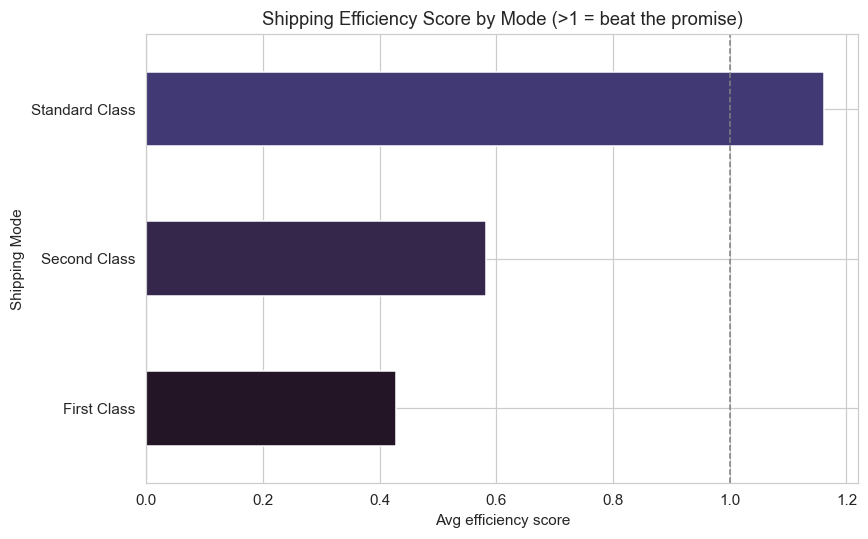

In [20]:
efficiency_by_mode = df.groupby("Shipping Mode")["shipping_efficiency_score"].mean().sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
efficiency_by_mode.plot(kind="barh", ax=ax, color=PALETTE)
ax.axvline(1.0, color="grey", linestyle="--", linewidth=1)
ax.set_title("Shipping Efficiency Score by Mode (>1 = beat the promise)")
ax.set_xlabel("Avg efficiency score")
plt.tight_layout()
plt.show()

**Read:** a mode below the dashed line is running slower than promised on average — the operational proxy for money spent on a service level that isn't being delivered.

## 10. Discount Analysis

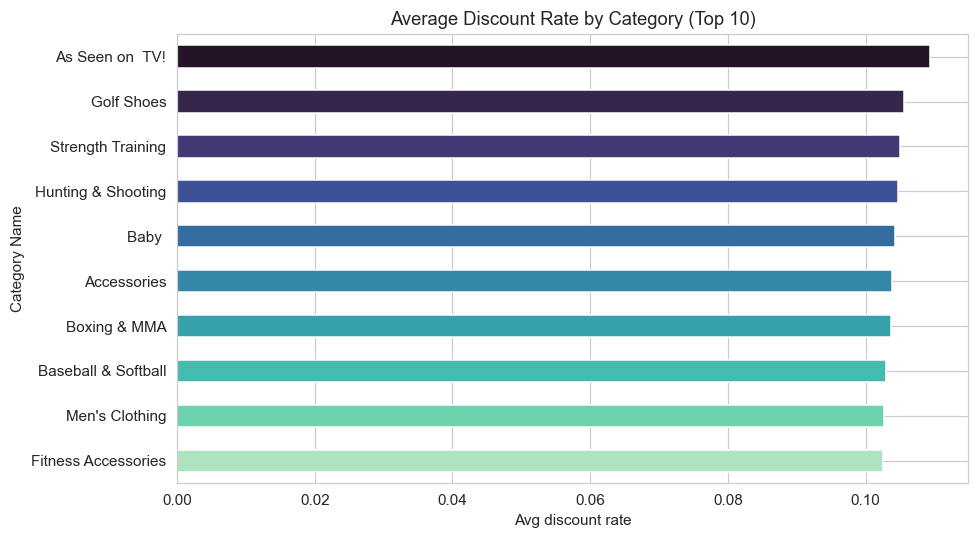

In [21]:
discount_by_category = df.groupby("Category Name")["Order Item Discount Rate"].mean().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(9, 5))
discount_by_category.plot(kind="barh", ax=ax, color=PALETTE)
ax.invert_yaxis()
ax.set_title("Average Discount Rate by Category (Top 10)")
ax.set_xlabel("Avg discount rate")
plt.tight_layout()
plt.show()

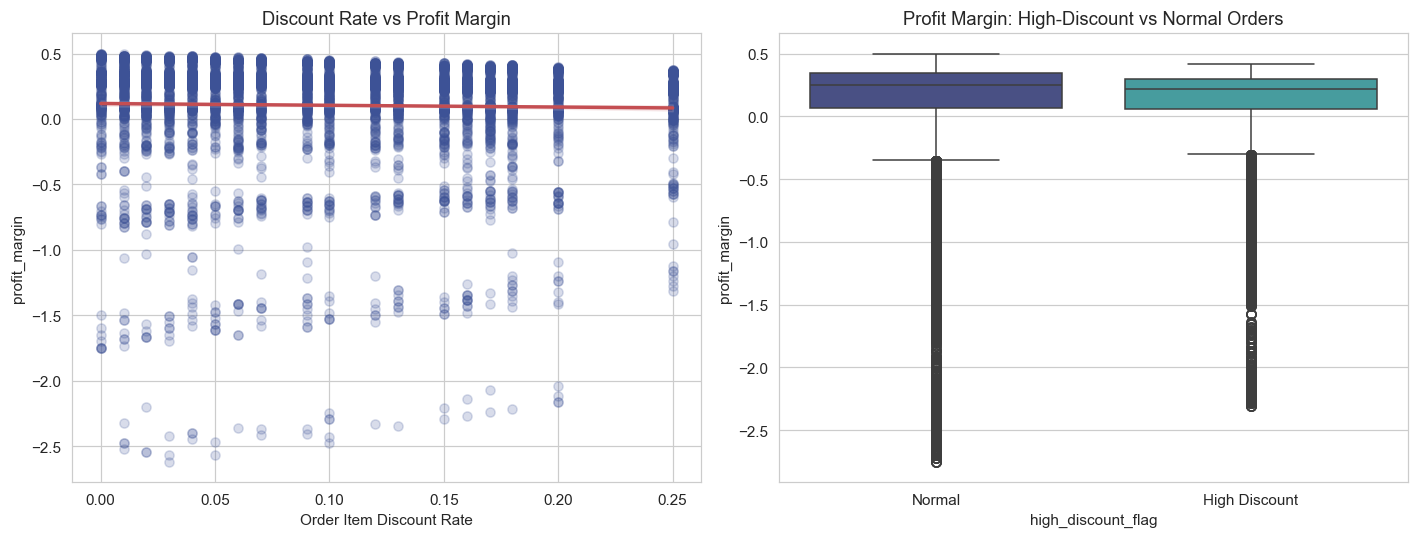

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.regplot(data=df.sample(min(5000, len(df)), random_state=42),
            x="Order Item Discount Rate", y="profit_margin",
            ax=axes[0], scatter_kws={"alpha": 0.2, "color": PALETTE[3]}, line_kws={"color": "#c44e52"})
axes[0].set_title("Discount Rate vs Profit Margin")

sns.boxplot(data=df, x="high_discount_flag", y="profit_margin", ax=axes[1], palette="mako")
axes[1].set_title("Profit Margin: High-Discount vs Normal Orders")
axes[1].set_xticklabels(["Normal", "High Discount"])

plt.tight_layout()
plt.show()

**Read:** a negative slope in the left panel, and a visibly lower median in the "High Discount" box
on the right, is the direct answer to "are discounts driving profitable growth or just eroding margin" — no
further test needed to make that call in a stakeholder deck.

## 11. Correlation Analysis

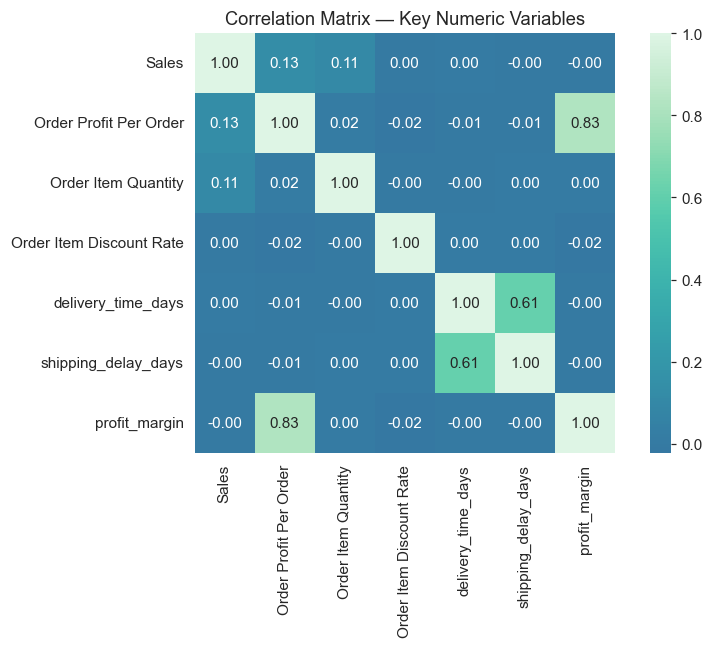

In [23]:
numeric_cols = [
    "Sales", "Order Profit Per Order", "Order Item Quantity", "Order Item Discount Rate",
    "delivery_time_days", "shipping_delay_days", "profit_margin",
]
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="mako", center=0, ax=ax, square=True)
ax.set_title("Correlation Matrix — Key Numeric Variables")
plt.tight_layout()
plt.show()

**Read:** the strongest relationships worth naming out loud in a writeup — `Sales` vs
`Order Profit Per Order`, and `delivery_time_days` vs `shipping_delay_days` (expected, since one is derived
from the other). Anything with `profit_margin` close to zero is a reminder that revenue size alone doesn't
predict margin — consistent with the revenue-vs-profit scatter in Section 3.

## 12. Summary

- **Executive KPIs:** revenue, profit, orders, customers, AOV, margin, delivery time, and late rate in one
  view — the numbers that open any stakeholder conversation.
- **Sales:** top/bottom products and categories, plus a concentration curve answering the diversification
  question directly.
- **Profitability:** category-level profit, and a revenue-vs-profit scatter separating revenue drivers from
  profit drivers.
- **Customers:** top-10 by spend, and the top-10%-of-customers revenue share as the dependency metric.
- **Product performance:** quantity vs revenue, and a demand-tier breakdown.
- **Shipping & delivery:** mode-level volume, late rate, and delay — the logistics bottleneck view.
- **Time series:** monthly revenue/profit trend (interactive) and quarterly performance.
- **Regional:** revenue-and-profit treemap by region, worst late-delivery countries.
- **Shipping cost (proxy):** efficiency score by mode, since no true cost column exists in this dataset.
- **Discounts:** discount rate by category, and its relationship to profit margin.
- **Correlations:** a single heatmap tying the numeric story together.

Every chart above is scoped to a question a stakeholder would actually ask — not every bullet in the
original list, by design.

In [24]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Delivery Status',
       'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City',
       ...
       'Shipping Mode_Standard Class', 'Customer Segment_Corporate',
       'Customer Segment_Home Office', 'Market_Europe', 'Market_Latam',
       'Market_Pacific Asia', 'Market_Usca',
       'delivery_performance_category_Late',
       'delivery_performance_category_On Time', 'Shipping Mode'],
      dtype='object', length=104)